In [14]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
import sqlite3

conn = sqlite3.connect("/content/northwind.db")

cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [16]:
conn = sqlite3.connect("/content/northwind.db")

print("Connected Successfully!")

Connected Successfully!


In [17]:
query1 = """
SELECT
    p.ProductName,
    SUM(od.Quantity) AS TotalSold
FROM "Order Details" AS od
JOIN Products AS p
ON od.ProductID = p.ProductID
GROUP BY p.ProductName
ORDER BY TotalSold DESC
LIMIT 10;
"""

top_products = pd.read_sql(query1, conn)
top_products

,ProductName,TotalSold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


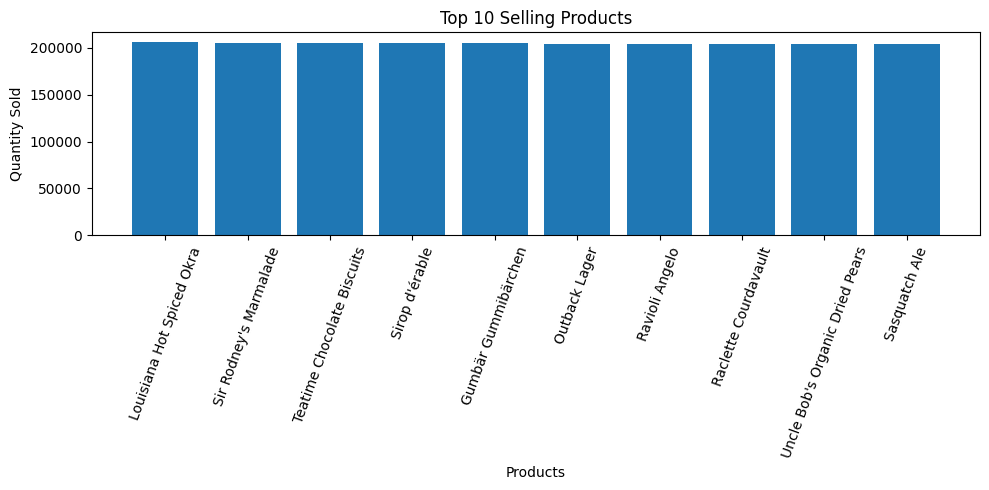

In [18]:
plt.figure(figsize=(10,5))

plt.bar(top_products["ProductName"], top_products["TotalSold"])

plt.xticks(rotation=70)

plt.title("Top 10 Selling Products")

plt.xlabel("Products")

plt.ylabel("Quantity Sold")

plt.tight_layout()

plt.show()

In [19]:
query2 = """
SELECT
    c.CompanyName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Customers c
JOIN Orders o
ON c.CustomerID = o.CustomerID
JOIN "Order Details" od
ON o.OrderID = od.OrderID
GROUP BY c.CompanyName
ORDER BY Revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query2, conn)
top_customers

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.81
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524517.31
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462198.02
9,LILA-Supermercado,5437438.34


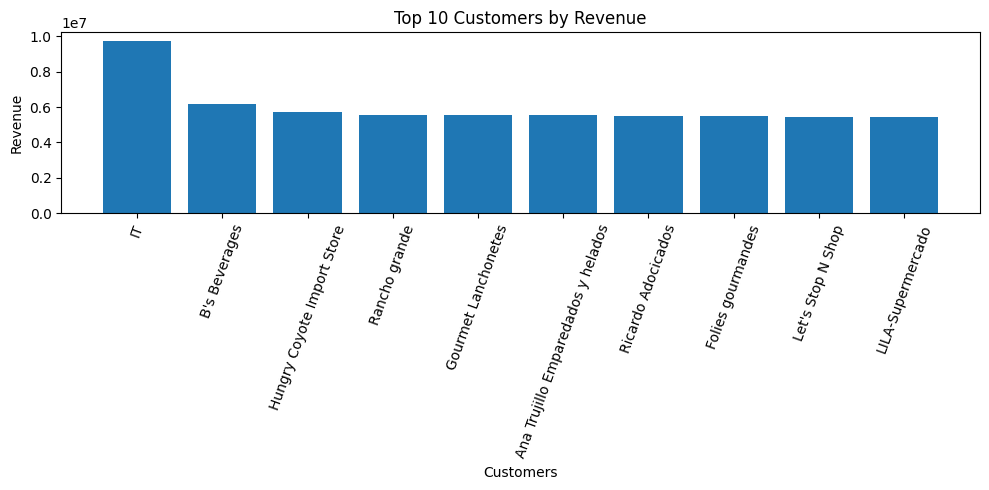

In [20]:
plt.figure(figsize=(10,5))

plt.bar(top_customers["CompanyName"], top_customers["Revenue"])

plt.xticks(rotation=70)

plt.title("Top 10 Customers by Revenue")

plt.xlabel("Customers")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [21]:
query3 = """
SELECT
    strftime('%Y-%m', o.OrderDate) AS Month,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Sales
FROM Orders o
JOIN "Order Details" od
ON o.OrderID = od.OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql(query3, conn)
monthly_sales

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51


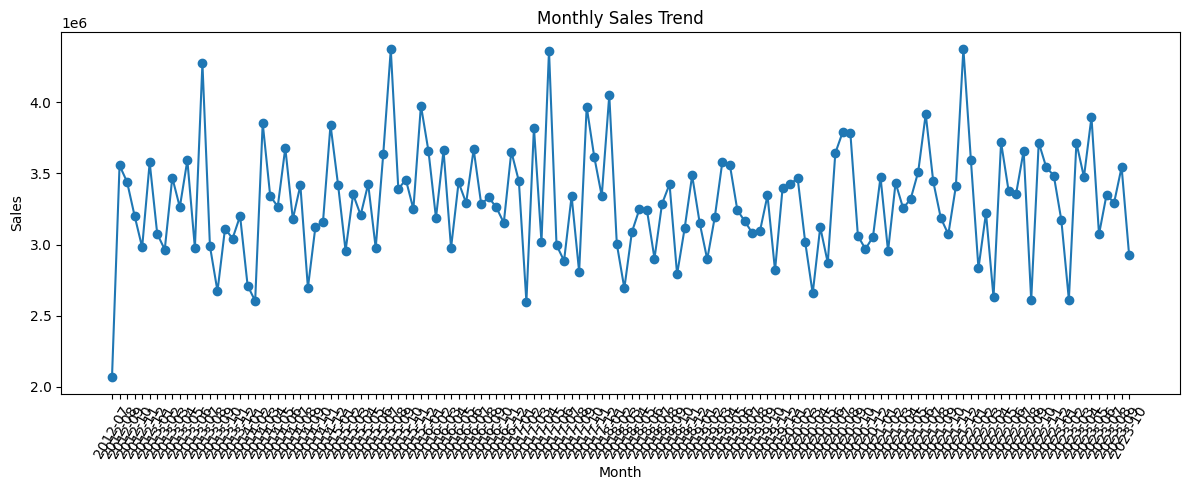

In [22]:
plt.figure(figsize=(12,5))

plt.plot(monthly_sales["Month"], monthly_sales["Sales"], marker="o")

plt.xticks(rotation=60)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.tight_layout()

plt.show()

In [23]:
query4 = """
SELECT
    c.CategoryName,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)),2) AS Revenue
FROM Categories c
JOIN Products p
ON c.CategoryID = p.CategoryID
JOIN "Order Details" od
ON p.ProductID = od.ProductID
GROUP BY c.CategoryName
ORDER BY Revenue DESC;
"""

categories = pd.read_sql(query4, conn)
categories

,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34


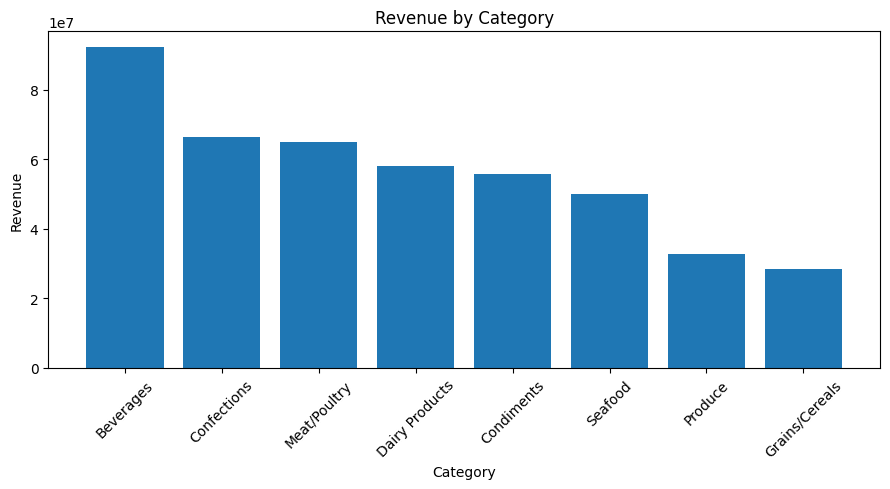

In [24]:
plt.figure(figsize=(9,5))

plt.bar(categories["CategoryName"], categories["Revenue"])

plt.xticks(rotation=45)

plt.title("Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [25]:
query5 = """
SELECT
    c.CompanyName,
    COUNT(o.OrderID) AS TotalOrders
FROM Customers c
JOIN Orders o
ON c.CustomerID = o.CustomerID
GROUP BY c.CompanyName
ORDER BY TotalOrders DESC;
"""

purchase_frequency = pd.read_sql(query5, conn)
purchase_frequency.head(10)

,CompanyName,TotalOrders
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202
5,Princesa Isabel Vinhos,200
6,Hungry Coyote Import Store,198
7,Tortuga Restaurante,197
8,Folies gourmandes,195
9,Ana Trujillo Emparedados y helados,195


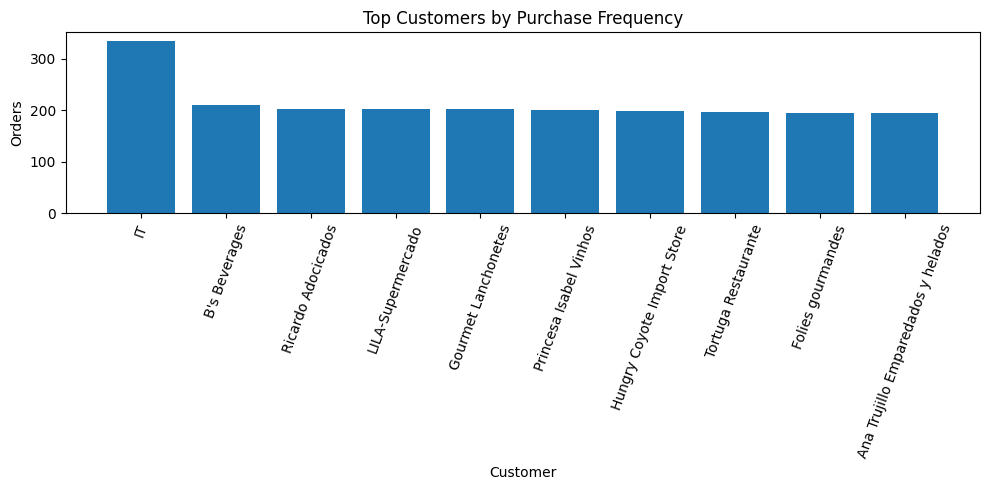

In [26]:
top_frequency = purchase_frequency.head(10)

plt.figure(figsize=(10,5))

plt.bar(top_frequency["CompanyName"], top_frequency["TotalOrders"])

plt.xticks(rotation=70)

plt.title("Top Customers by Purchase Frequency")

plt.xlabel("Customer")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

In [27]:
print("Top Products")
display(top_products)

print("\nTop Customers")
display(top_customers)

print("\nMonthly Sales")
display(monthly_sales)

print("\nCategories")
display(categories)

print("\nPurchase Frequency")
display(purchase_frequency.head(10))

Top Products


,ProductName,TotalSold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667



Top Customers


,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.81
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524517.31
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462198.02
9,LILA-Supermercado,5437438.34



Monthly Sales


,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51



Categories


,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34



Purchase Frequency


,CompanyName,TotalOrders
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202
5,Princesa Isabel Vinhos,200
6,Hungry Coyote Import Store,198
7,Tortuga Restaurante,197
8,Folies gourmandes,195
9,Ana Trujillo Emparedados y helados,195


In [28]:
conn.close()

print("Database connection closed.")

Database connection closed.
